In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q nnunetv2 nibabel scipy pandas seaborn matplotlib

import os
BASE = '/content/drive/MyDrive/brats_project'
os.makedirs(BASE, exist_ok=True)

# raw + preprocessed: local disk (tez). results/checkpoints: Drive (safe)
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = f'{BASE}/nnUNet_results'
for k in ['nnUNet_raw','nnUNet_preprocessed','nnUNet_results']:
    os.makedirs(os.environ[k], exist_ok=True)
    print(k, '->', os.environ[k])

!nvidia-smi

Mounted at /content/drive
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 10.9 MB/s eta 0:00:00
nnUNet_raw -> /content/nnUNet_raw
nnUNet_preproce

In [2]:
import torch
print(torch.__version__, torch.cuda.is_available())
!which nnUNetv2_train

2.11.0+cu130 True
/usr/local/bin/nnUNetv2_train


In [3]:
%cd /content
!mkdir -p data && cd data && wget -c https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar
!cd /content/data && tar -xf Task01_BrainTumour.tar
# macOS junk files jo nnU-Net ko tod dete hain
!find /content/data -name "._*" -delete
!ls /content/data/Task01_BrainTumour

/content
--2026-10-06 07:09:00--  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar
Resolving msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)... 16.15.38.31, 52.92.148.10, 52.92.237.138, ...
Connecting to msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)|16.15.38.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7608266240 (7.1G) [application/x-tar]
Saving to: ‘Task01_BrainTumour.tar’

Task01_BrainTumour. 100%[===================>]   7.08G  55.6MB/s    in 2m 46s  

2026-10-06 07:11:47 (43.6 MB/s) - ‘Task01_BrainTumour.tar’ saved [7608266240/7608266240]

dataset.json  imagesTr	imagesTs  labelsTr


In [4]:
!nnUNetv2_convert_MSD_dataset -i /content/data/Task01_BrainTumour
!ls $nnUNet_raw
!cat $nnUNet_raw/Dataset001_BrainTumour/dataset.json

Dataset001_BrainTumour
{
    "name": "BRATS",
    "description": "Gliomas segmentation tumour and oedema in on brain images",
    "reference": "https://www.med.upenn.edu/sbia/brats2017.html",
    "licence": "CC-BY-SA 4.0",
    "release": "2.0 04/05/2018",
    "tensorImageSize": "4D",
    "labels": {
        "background": 0,
        "edema": 1,
        "non-enhancing tumor": 2,
        "enhancing tumour": 3
    },
    "numTraining": 484,
    "numTest": 266,
    "file_ending": ".nii.gz",
    "channel_names": {
        "0": "FLAIR",
        "1": "T1w",
        "2": "t1gd",
        "3": "T2w"
    }
}

In [5]:
!ls /content/nnUNet_raw/Dataset001_BrainTumour/imagesTr | wc -l
!ls /content/nnUNet_raw/Dataset001_BrainTumour/labelsTr | wc -l

1936
484


In [6]:
import os, glob, json, random, shutil

RAW = f"{os.environ['nnUNet_raw']}/Dataset001_BrainTumour"
HELD = '/content/heldout'
N_TEST  = 40
N_TRAIN = 150          # None = sab use karo
SEED = 42

cases = sorted(os.path.basename(f)[:-7] for f in glob.glob(f'{RAW}/labelsTr/*.nii.gz'))
print('total cases:', len(cases))
random.Random(SEED).shuffle(cases)
test_cases  = cases[:N_TEST]
train_cases = cases[N_TEST:]
if N_TRAIN:
    unused = train_cases[N_TRAIN:]
    train_cases = train_cases[:N_TRAIN]
else:
    unused = []

os.makedirs(f'{HELD}/images', exist_ok=True)
os.makedirs(f'{HELD}/labels', exist_ok=True)
os.makedirs('/content/unused', exist_ok=True)

for c in test_cases:
    for f in glob.glob(f'{RAW}/imagesTr/{c}_*.nii.gz'):
        shutil.move(f, f'{HELD}/images/')
    shutil.move(f'{RAW}/labelsTr/{c}.nii.gz', f'{HELD}/labels/')
for c in unused:
    for f in glob.glob(f'{RAW}/imagesTr/{c}_*.nii.gz'):
        shutil.move(f, '/content/unused/')
    shutil.move(f'{RAW}/labelsTr/{c}.nii.gz', '/content/unused/')

shutil.rmtree(f'{RAW}/imagesTs', ignore_errors=True)

dj = json.load(open(f'{RAW}/dataset.json'))
dj['numTraining'] = len(train_cases)
json.dump(dj, open(f'{RAW}/dataset.json','w'), indent=2)

json.dump({'train':train_cases,'test':test_cases}, open(f'{BASE}/split.json','w'))
print('train:', len(train_cases), 'test:', len(test_cases))

total cases: 484
train: 150 test: 40


In [7]:
!nnUNetv2_plan_and_preprocess -d 1 -c 3d_fullres --verify_dataset_integrity -np 4

Fingerprint extraction...
Dataset001_BrainTumour
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 150/150 [03:03<00:00,  1.22s/it]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [137. 169. 138.], 3d_lowres: [137, 169, 138]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'ba

In [8]:
!du -sh $nnUNet_preprocessed/Dataset001_BrainTumour
!df -h /content/drive | tail -1

2.1G	/content/nnUNet_preprocessed/Dataset001_BrainTumour
drive            15G  8.0G  7.1G  54% /content/drive


In [11]:
import nnunetv2, os
d = os.path.join(nnunetv2.__path__[0], 'training', 'nnUNetTrainer')
code = '''
import torch
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer

class nnUNetTrainer_15epochs(nnUNetTrainer):
    def __init__(self, plans, configuration, fold, dataset_json, device=torch.device('cuda')):
        super().__init__(plans, configuration, fold, dataset_json, device)
        self.num_epochs = 15
        self.save_every = 1
'''
open(os.path.join(d, 'nnUNetTrainer_15epochs.py'), 'w').write(code)

359

In [12]:
TRAINER = 'nnUNetTrainer_15epochs'
!nnUNetv2_train 1 3d_fullres 0 -tr {TRAINER}


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-10-06 08:01:13.685861: Using torch.compile...
2026-10-06 08:01:15.356290: do_dummy_2d_data_aug: False
2026-10-06 08:01:15.362391: Using splits from existing split file: /content/nnUNet_preprocessed/Dataset001_BrainTumour/splits_final.json
2026-10-06 08:01:15.370044: The split file contains 

In [13]:
import os, glob, json
BASE = '/content/drive/MyDrive/brats_project'
TRAINER = 'nnUNetTrainer_15epochs'
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = f'{BASE}/nnUNet_results'

!ls {BASE}/nnUNet_results/Dataset001_BrainTumour/nnUNetTrainer_15epochs__nnUNetPlans__3d_fullres/fold_0
!ls /content/heldout/images | wc -l

checkpoint_best.pth   progress.png			   validation
checkpoint_final.pth  training_log_2026_10_6_07_59_00.txt
debug.json	      training_log_2026_10_6_08_01_12.txt
160


In [14]:
!cp -r /content/heldout {BASE}/heldout_backup

In [15]:
import os, glob, json
BASE = '/content/drive/MyDrive/brats_project'
TRAINER = 'nnUNetTrainer_15epochs'
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = f'{BASE}/nnUNet_results'

PRED = '/content/pred_baseline'
!nnUNetv2_predict -i /content/heldout/images -o {PRED} -d 1 -c 3d_fullres -f 0 -tr {TRAINER} -chk checkpoint_final.pth --save_probabilities


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 40 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 40 cases that I would like to predict

Predicting BRATS_005:
perform_everything_on_device: True
100% 8/8 [00:10<00:00,  1.31s/it]
sending off prediction to background worker for resampling and export
done with BRATS_005

Predicting BRATS_008:
perform_everything_on_device: True
100% 8/8 [00:06<00:00,  1.18it/s]
sending off prediction to background worker for resampling and export
done with BRATS_008

Predicting BRATS_022:
perform_everything_on_device: True
100% 8/8 [00:0

In [16]:
import numpy as np, pandas as pd, nibabel as nib, glob, os, json
from scipy.ndimage import distance_transform_edt, binary_erosion

REGIONS = {'WT':[1,2,3], 'TC':[2,3], 'ET':[3]}

def dice(a, b):
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else 2.0*np.logical_and(a, b).sum()/s

def hd95(a, b, spacing):
    if a.sum()==0 and b.sum()==0: return 0.0
    if a.sum()==0 or b.sum()==0:  return np.nan
    sa = a ^ binary_erosion(a)
    sb = b ^ binary_erosion(b)
    dtb = distance_transform_edt(~sb, sampling=spacing)
    dta = distance_transform_edt(~sa, sampling=spacing)
    d = np.concatenate([dtb[sa], dta[sb]])
    return float(np.percentile(d, 95))

def eval_folder(pred_dir, gt_dir='/content/heldout/labels'):
    rows = []
    for gf in sorted(glob.glob(f'{gt_dir}/*.nii.gz')):
        case = os.path.basename(gf)[:-7]
        pf = f'{pred_dir}/{case}.nii.gz'
        if not os.path.exists(pf): continue
        g_img = nib.load(gf); gt = np.asarray(g_img.dataobj).astype(np.uint8)
        pr = np.asarray(nib.load(pf).dataobj).astype(np.uint8)
        sp = g_img.header.get_zooms()[:3]
        row = {'case': case, 'gt_WT_vox': int(np.isin(gt,[1,2,3]).sum()),
               'gt_ET_vox': int((gt==3).sum())}
        for r, labs in REGIONS.items():
            a, b = np.isin(gt, labs), np.isin(pr, labs)
            row[f'Dice_{r}'] = dice(a, b)
            row[f'HD95_{r}'] = hd95(a, b, sp)
        rows.append(row)
    return pd.DataFrame(rows)

def unc_folder(pred_dir):
    rows = []
    for nf in sorted(glob.glob(f'{pred_dir}/*.npz')):
        case = os.path.basename(nf)[:-4]
        p = np.load(nf)['probabilities'].astype(np.float32)
        ent = -(p * np.log(p + 1e-8)).sum(axis=0)
        cand = p[0] < 0.95
        n = int(cand.sum())
        rows.append({'case': case,
                     'U_mean': float(ent[cand].mean()) if n else 0.0,
                     'U_sum':  float(ent[cand].sum()),
                     'cand_vox': n})
        del p, ent
    return pd.DataFrame(rows)

df_base = eval_folder('/content/pred_baseline')
df_base = df_base.merge(unc_folder('/content/pred_baseline'), on='case')
df_base.to_csv(f'{BASE}/baseline_per_case.csv', index=False)
display(df_base.round(3))
cols = [c for c in df_base.columns if c.startswith(('Dice','HD95','U_'))]
print(df_base[cols].agg(['mean','std']).round(3))

,case,gt_WT_vox,gt_ET_vox,Dice_WT,HD95_WT,Dice_TC,HD95_TC,Dice_ET,HD95_ET,U_mean,U_sum,cand_vox
0,BRATS_005,80680,18353,0.851,5.657,0.812,9.487,0.654,9.581,0.221,18998.621,85943
1,BRATS_008,187569,36577,0.934,2.828,0.902,7.280,0.866,2.236,0.230,50310.367,218546
2,BRATS_022,248231,9546,0.944,3.317,0.765,9.434,0.606,9.055,0.243,69169.781,284617
3,BRATS_042,32572,352,0.852,11.769,0.720,35.968,0.000,NaN,0.228,11286.523,49408
4,BRATS_046,116161,78688,0.927,25.020,0.934,2.828,0.937,1.414,0.206,26026.299,126642
5,BRATS_051,111078,19020,0.948,1.732,0.946,2.828,0.913,1.000,0.129,14633.196,113197
6,BRATS_060,149255,24120,0.907,4.583,0.839,6.708,0.720,2.000,0.270,46801.102,173362
7,BRATS_095,36298,3395,0.812,16.155,0.659,7.348,0.927,1.000,0.241,15842.641,65825
8,BRATS_097,153175,41792,0.948,2.236,0.875,10.296,0.917,1.000,0.183,29901.127,163799
9,BRATS_130,56136,132,0.925,2.236,0.397,8.225,0.037,15.681,0.220,14898.729,67733


      Dice_WT  HD95_WT  Dice_TC  HD95_TC  Dice_ET  HD95_ET  U_mean      U_sum
mean    0.890    7.921    0.801    9.240    0.744    4.894   0.219  25989.077
std     0.066    7.862    0.171    8.589    0.270    7.239   0.044  15961.497


{'0': 'FLAIR', '1': 'T1w', '2': 't1gd', '3': 'T2w'}


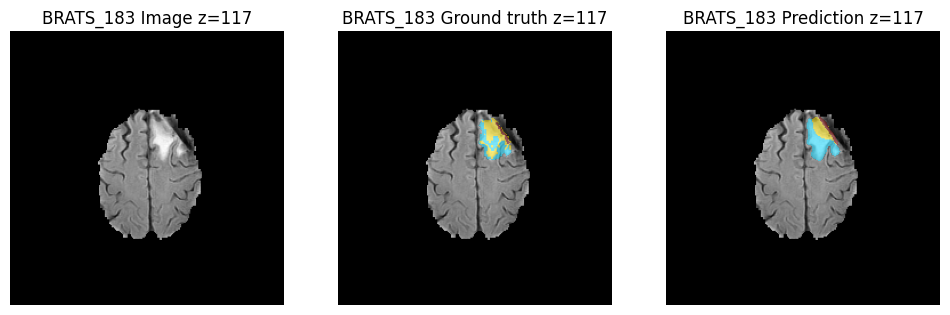

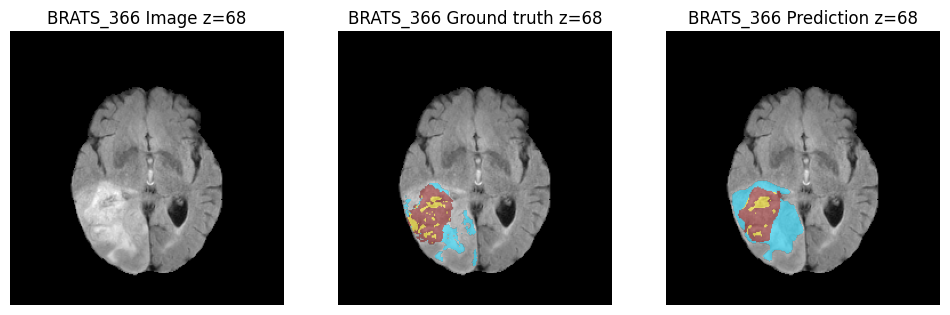

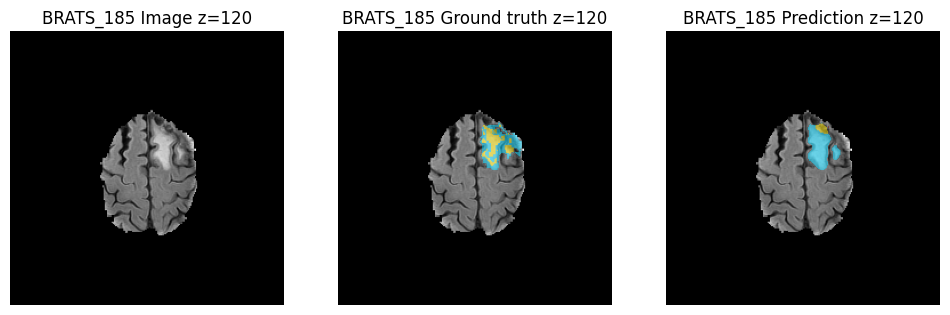

In [17]:
import matplotlib.pyplot as plt

dj = json.load(open(f"{os.environ['nnUNet_raw']}/Dataset001_BrainTumour/dataset.json"))
print(dj['channel_names'])

def show_case(case, ch=0, pred_dir='/content/pred_baseline'):
    img = np.asarray(nib.load(f'/content/heldout/images/{case}_{ch:04d}.nii.gz').dataobj)
    gt  = np.asarray(nib.load(f'/content/heldout/labels/{case}.nii.gz').dataobj)
    pr  = np.asarray(nib.load(f'{pred_dir}/{case}.nii.gz').dataobj)
    z = int(np.argmax((gt>0).sum(axis=(0,1))))
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    for a, m, t in zip(ax, [None, gt, pr], ['Image','Ground truth','Prediction']):
        a.imshow(img[:,:,z].T, cmap='gray', origin='lower')
        if m is not None:
            a.imshow(np.ma.masked_where(m[:,:,z].T==0, m[:,:,z].T), cmap='jet',
                     alpha=0.5, origin='lower', vmin=0, vmax=3)
        a.set_title(f'{case} {t} z={z}'); a.axis('off')
    plt.show()

for c in df_base.sort_values('Dice_WT').case.head(3):
    show_case(c)

         case   Dice_WT   Dice_TC   Dice_ET  gt_WT_vox  gt_ET_vox    U_mean
17  BRATS_183  0.642076  0.296712  0.593805      16647        650  0.290330
34  BRATS_366  0.752028  0.904702  0.846840      89189      37598  0.217121
18  BRATS_185  0.774637  0.213851  0.000000      31817        108  0.272747
21  BRATS_197  0.784974  0.704923  0.565818     113287       4158  0.332786
7   BRATS_095  0.812079  0.658798  0.927280      36298       3395  0.240678


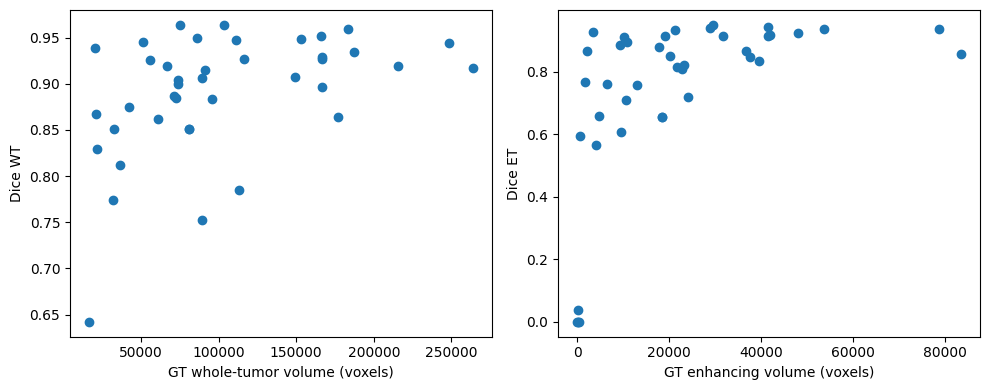

In [18]:
d = df_base.copy()
print(d.sort_values('Dice_WT').head(5)[['case','Dice_WT','Dice_TC','Dice_ET','gt_WT_vox','gt_ET_vox','U_mean']])

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(d.gt_WT_vox, d.Dice_WT); ax[0].set_xlabel('GT whole-tumor volume (voxels)'); ax[0].set_ylabel('Dice WT')
ax[1].scatter(d.gt_ET_vox, d.Dice_ET); ax[1].set_xlabel('GT enhancing volume (voxels)'); ax[1].set_ylabel('Dice ET')
plt.tight_layout(); plt.savefig(f'{BASE}/fail_vs_volume.png', dpi=200); plt.show()

In [19]:
ch_names = {int(k): v.lower() for k, v in dj['channel_names'].items()}
name2idx = {v: k for k, v in ch_names.items()}
print(name2idx)
FL, T1, T1C, T2 = name2idx['flair'], name2idx['t1w'], name2idx['t1gd'], name2idx['t2w']

COMBOS = {
    'All4':       [FL,T1,T1C,T2],
    'no_T1ce':    [FL,T1,T2],
    'no_FLAIR':   [T1,T1C,T2],
    'FLAIR_only': [FL],
    'T1ce_only':  [T1C],
    'FLAIR+T1ce': [FL,T1C],
}
N_EVAL = 20

def make_variants(EXP):
    ZERO = f'{EXP}/zeros'; os.makedirs(ZERO, exist_ok=True)
    tc = json.load(open(f'{BASE}/split.json'))['test'][:N_EVAL]
    for c in tc:
        src = nib.load(f'/content/heldout/images/{c}_0000.nii.gz')
        nib.save(nib.Nifti1Image(np.zeros(src.shape, dtype=np.float32), src.affine, src.header),
                 f'{ZERO}/{c}.nii.gz')
    for name, keep in COMBOS.items():
        d_in = f'{EXP}/{name}/images'; os.makedirs(d_in, exist_ok=True)
        for c in tc:
            for ch in range(4):
                dst = f'{d_in}/{c}_{ch:04d}.nii.gz'
                if os.path.lexists(dst): os.remove(dst)
                src = f'/content/heldout/images/{c}_{ch:04d}.nii.gz' if ch in keep else f'{ZERO}/{c}.nii.gz'
                os.symlink(src, dst)
    return tc

EXP = '/content/exp'
test_cases = make_variants(EXP)
print('done', len(test_cases))

{'flair': 0, 't1w': 1, 't1gd': 2, 't2w': 3}
done 20


In [20]:
import subprocess

def run_combos(trainer, exp_dir, tag):
    results = []
    for name in COMBOS:
        out = f'{exp_dir}/{name}/pred'
        csv = f'{BASE}/{tag}_{name}.csv'
        if os.path.exists(csv):
            results.append(pd.read_csv(csv)); continue
        cmd = (f'nnUNetv2_predict -i {exp_dir}/{name}/images -o {out} -d 1 -c 3d_fullres -f 0 '
               f'-tr {trainer} -chk checkpoint_final.pth --disable_tta --save_probabilities')
        subprocess.run(cmd, shell=True, check=True)
        df = eval_folder(out).merge(unc_folder(out), on='case')
        df['combo'] = name
        df.to_csv(csv, index=False)
        for f in glob.glob(f'{out}/*.npz') + glob.glob(f'{out}/*.pkl'):
            os.remove(f)
        results.append(df)
        print(name, df[['Dice_WT','Dice_TC','Dice_ET','U_mean']].mean().round(3).to_dict())
    allr = pd.concat(results, ignore_index=True)
    allr.to_csv(f'{BASE}/{tag}_all.csv', index=False)
    return allr

allr = run_combos(TRAINER, EXP, 'exp_baseline')

All4 {'Dice_WT': 0.889, 'Dice_TC': 0.781, 'Dice_ET': 0.717, 'U_mean': 0.218}
no_T1ce {'Dice_WT': 0.868, 'Dice_TC': 0.556, 'Dice_ET': 0.118, 'U_mean': 0.305}
no_FLAIR {'Dice_WT': 0.134, 'Dice_TC': 0.231, 'Dice_ET': 0.154, 'U_mean': 0.476}
FLAIR_only {'Dice_WT': 0.745, 'Dice_TC': 0.213, 'Dice_ET': 0.004, 'U_mean': 0.275}
T1ce_only {'Dice_WT': 0.002, 'Dice_TC': 0.001, 'Dice_ET': 0.001, 'U_mean': 0.461}
FLAIR+T1ce {'Dice_WT': 0.712, 'Dice_TC': 0.48, 'Dice_ET': 0.423, 'U_mean': 0.304}


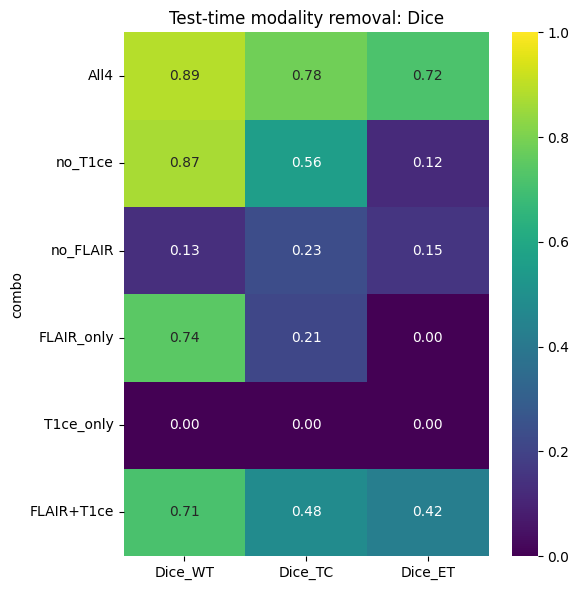

            Dice_WT  Dice_TC  Dice_ET
combo                                
All4          0.889    0.781    0.717
no_T1ce       0.868    0.556    0.118
no_FLAIR      0.134    0.231    0.154
FLAIR_only    0.745    0.213    0.004
T1ce_only     0.002    0.001    0.001
FLAIR+T1ce    0.712    0.480    0.423


In [21]:
import seaborn as sns
tab = allr.groupby('combo')[['Dice_WT','Dice_TC','Dice_ET']].mean().loc[list(COMBOS)]
plt.figure(figsize=(6,6))
sns.heatmap(tab, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1)
plt.title('Test-time modality removal: Dice'); plt.tight_layout()
plt.savefig(f'{BASE}/exp_heatmap.png', dpi=250); plt.show()
print(tab.round(3))

            Dice_WT  U_mean      U_sum
combo                                 
All4          0.889   0.218  25268.462
no_T1ce       0.868   0.305  34419.748
no_FLAIR      0.134   0.476  13490.042
FLAIR_only    0.745   0.275  32563.564
T1ce_only     0.002   0.461  17295.912
FLAIR+T1ce    0.712   0.304  33963.117


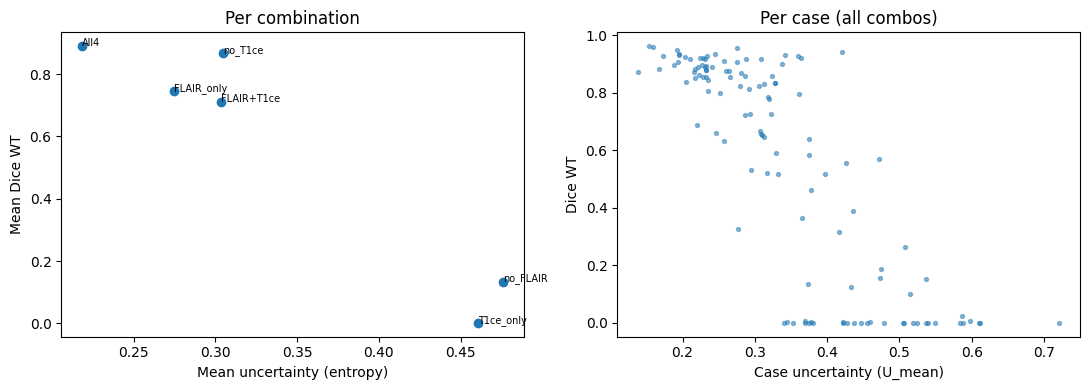

In [22]:
summ = allr.groupby('combo')[['Dice_WT','U_mean','U_sum']].mean().loc[list(COMBOS)]
print(summ.round(3))

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].scatter(summ.U_mean, summ.Dice_WT)
for n, r in summ.iterrows(): ax[0].annotate(n, (r.U_mean, r.Dice_WT), fontsize=7)
ax[0].set_xlabel('Mean uncertainty (entropy)'); ax[0].set_ylabel('Mean Dice WT'); ax[0].set_title('Per combination')
ax[1].scatter(allr.U_mean, allr.Dice_WT, s=8, alpha=0.5)
ax[1].set_xlabel('Case uncertainty (U_mean)'); ax[1].set_ylabel('Dice WT'); ax[1].set_title('Per case (all combos)')
plt.tight_layout(); plt.savefig(f'{BASE}/unc_vs_dice.png', dpi=250); plt.show()

Spearman(U_mean, Dice_WT) pooled: rho=-0.809, p=5.4e-29  (negative honi chahiye)
  All4         rho=-0.693
  FLAIR+T1ce   rho=-0.895
  FLAIR_only   rho=-0.426
  T1ce_only    rho=-0.193
  no_FLAIR     rho=-0.498
  no_T1ce      rho=0.000
bad cases: 58 of 120
AUROC (U_mean -> bad seg): 0.933
AUROC (U_sum  -> bad seg): 0.354


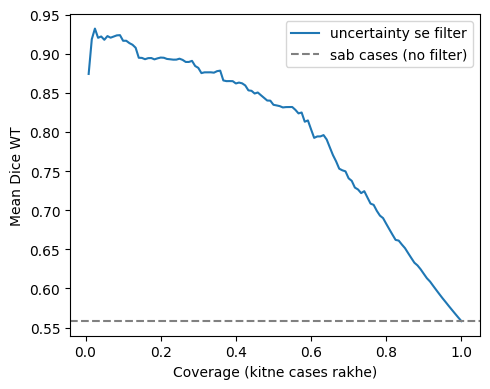

In [23]:
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

THR = 0.7
x = allr.dropna(subset=['U_mean','Dice_WT']).copy()

rho, pval = spearmanr(x.U_mean, x.Dice_WT)
print(f'Spearman(U_mean, Dice_WT) pooled: rho={rho:.3f}, p={pval:.2g}  (negative honi chahiye)')

for c, g in x.groupby('combo'):
    if g.U_mean.nunique() > 1:
        print(f'  {c:12s} rho={spearmanr(g.U_mean, g.Dice_WT)[0]:.3f}')

bad = (x.Dice_WT < THR).astype(int)
print('bad cases:', bad.sum(), 'of', len(bad))
if 0 < bad.sum() < len(bad):
    print('AUROC (U_mean -> bad seg):', round(roc_auc_score(bad, x.U_mean), 3))
    print('AUROC (U_sum  -> bad seg):', round(roc_auc_score(bad, x.U_sum), 3))

xs = x.sort_values('U_mean').reset_index(drop=True)
cov = np.arange(1, len(xs)+1) / len(xs)
mean_dice_kept = xs.Dice_WT.expanding().mean()
plt.figure(figsize=(5,4))
plt.plot(cov, mean_dice_kept, label='uncertainty se filter')
plt.axhline(x.Dice_WT.mean(), ls='--', c='gray', label='sab cases (no filter)')
plt.xlabel('Coverage (kitne cases rakhe)'); plt.ylabel('Mean Dice WT')
plt.legend(); plt.tight_layout(); plt.savefig(f'{BASE}/risk_coverage.png', dpi=250); plt.show()

In [24]:
ex = x[x.case == x.case.iloc[0]][['combo','Dice_WT','Dice_ET','U_mean']].set_index('combo').loc[list(COMBOS)]
print(ex.round(3))

            Dice_WT  Dice_ET  U_mean
combo                               
All4          0.850    0.654   0.218
no_T1ce       0.826    0.078   0.280
no_FLAIR      0.264    0.016   0.508
FLAIR_only    0.690    0.000   0.220
T1ce_only     0.000    0.000   0.456
FLAIR+T1ce    0.655    0.349   0.310


In [25]:
!ls {BASE}

baseline_per_case.csv	     exp_baseline_no_FLAIR.csv	 heldout_backup
exp_baseline_All4.csv	     exp_baseline_no_T1ce.csv	 nnUNet_results
exp_baseline_all.csv	     exp_baseline_T1ce_only.csv  risk_coverage.png
exp_baseline_FLAIR_only.csv  exp_heatmap.png		 split.json
exp_baseline_FLAIR+T1ce.csv  fail_vs_volume.png		 unc_vs_dice.png
